# Monte Carlo Markov Chain (MCMC)


A **Markov Chain** is a random walk that maintains the **memoryless property**. In other words, each step, or probability, in the system is independent of the previous. 

## Random numbers (pseudo random)

Before moving in details, let's consider some kinds of randon numbers generators:

In [6]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

In [17]:
#Función randint: genera un número aleatorio entero entre 0 y n, siendo el segundo valor 30 en este caso.

print('randint =',random.randint(0, 10))

#Función uniform: nos permite generar valores aleatorios que sean decimales podemos hacer uso de uniform.
print('uniform =',random.uniform(0, 10))

#Función random: random que no acepta parámetros y genera números aleatorios decimales de entre 0 y 1.
print('random =',random.random())

#Función choice:nos permite elegir un elemento aleatorio de una lista.
fruits = ['11', '22', '33']
print('choice =',random.choice(fruits))



randint = 7
uniform = 5.547249165474928
random = 0.27339769165530836
choice = 33


## The Drunkard’s Walk ... the random walk

Let's consider a drunk wall where in each step the drunk man maintains the same probability of moving forwards or backwards whether he’s on the cliff’s edge or many steps away from it.

**1D Random Walk**
This example simulates a one-dimensional random walk where a walker starts at a fixed point and moves left or right randomly at each step. The path of the walker is plotted using matplotlib.
https://www.geeksforgeeks.org/python/random-walk-implementation-python/

In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

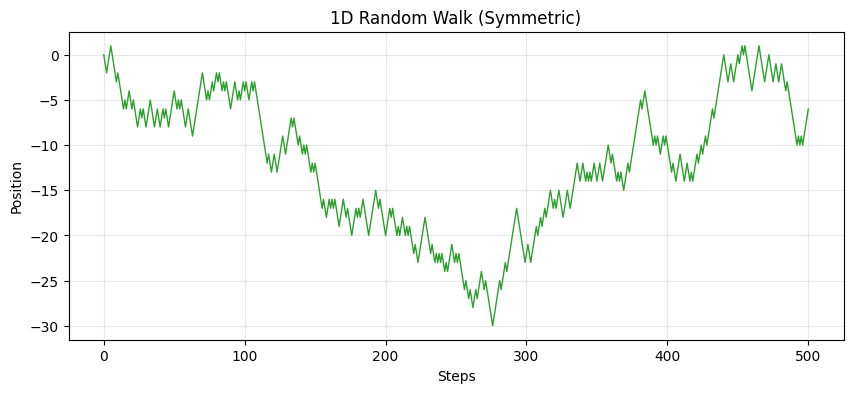

In [3]:
steps = 500
origin = 0

step_set = np.array([-1, 1]) # two posible values
random_steps = np.random.choice(step_set, size=steps) # choice between -1 o +1

path = np.concatenate([[origin], np.cumsum(random_steps)]) # np.cumsum suma las numeros del array sucesivamente

plt.figure(figsize=(10, 4))
plt.plot(path, color='#2ca02c', linewidth=1)
plt.title("1D Random Walk (Symmetric)")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.grid(True, alpha=0.3)
plt.show()

Explanation:

* origin = 0 walker starts at position 0.
* step_set = np.array([-1, 1]) each step can be -1 (left) or +1 (right).
* np.random.choice(step_set, size=steps) randomly select steps for the walk.
* np.cumsum(random_steps) compute cumulative sum to get walker’s position at each step.
* plt.plot(path) plot the full random walk path along the number line.

**2D Random Walk in Python**
A 2D random walk lets the walker move in four directions up, down, left or right creating more complex paths compared to 1D. The final path is plotted to visualize the movement on a 2D plane.

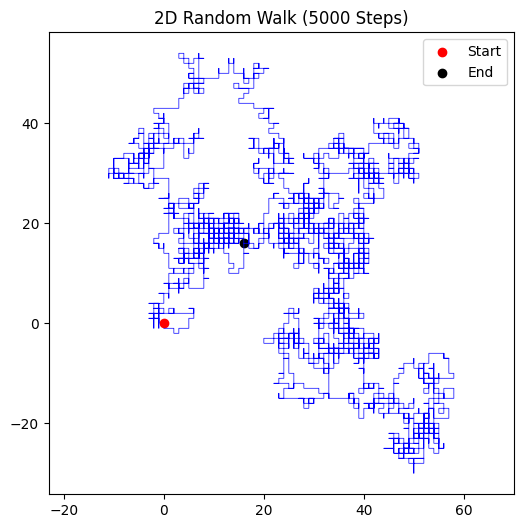

In [5]:
#import numpy as np
#import matplotlib.pyplot as plt

n = 5000
moves = np.array([(0, 1), (0, -1), (1, 0), (-1, 0)])

random_indices = np.random.choice(len(moves), size=n)
steps = moves[random_indices]

coords = np.cumsum(steps, axis=0)
x, y = coords[:, 0], coords[:, 1]

plt.figure(figsize=(6, 6))
plt.plot(x, y, lw=0.5, color='blue')
plt.scatter(0, 0, color='red', label='Start')
plt.scatter(x[-1], y[-1], color='black', label='End')
plt.title(f"2D Random Walk ({n} Steps)")
plt.legend()
plt.axis('equal')
plt.show()

**Explanation:**

* moves = np.array([(0,1),(0,-1),(1,0),(-1,0)]) define possible moves: up, down, right, left.
* np.random.choice(len(moves), size=n) randomly select n moves.
* steps = moves[random_indices] create sequence of steps for the walk.
* np.cumsum(steps, axis=0) compute cumulative (x, y) positions for the walker.
* plt.plot(x, y) plot the 2D path; plt.scatter marks start (red) and end (black).
* plt.axis('equal') ensures x and y axes have the same scale for accurate visualization.

## Metropolis-Hastings method

Uno de los métodos MCMC más populares es el algoritmo Metropolis-Hastings; de hecho la mayoría de los algoritmos de MCMC pueden ser interpretados como casos especiales de este algoritmo. El algoritmo Metropolis-Hastings esta catalogado como uno de los 10 algoritmos más importantes y más utilizados en ciencia e ingeniería en los últimos veinte años. Se encuentra en el corazón de la mayoría de los métodos de muestreo MCMC. **El problema básico que intenta resolver el algoritmo Metropolis-Hastings es proporcionar un método para generar muestras de alguna distribución genérica $P(x)$.
La idea es que en muchos casos, podemos saber cómo escribir la ecuación para la distribución de probabilidad $P(x)$, pero no sabemos cómo generar muestras aleatorias de la misma**. Entonces la idea básica detrás de este algoritmo es la de construir una cadena de Markov cuya distribución invariante sea la distribución de muestreo que deseamos, es decir $P(x)$. En principio, esto puede parecer bastante complicado, pero la flexibilidad inherente en la elección de las probabilidades de transición lo hacen más simple de lo que parece.

¿cómo funciona? ver:
https://relopezbriega.github.io/blog/2017/01/10/introduccion-a-los-metodos-de-monte-carlo-con-python/

In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

Normal distribution:

$p(x;\mu,\sigma^2)=\dfrac{1}{\sigma \sqrt{2\pi}} e^{-\dfrac{1}{2}\left(\dfrac{x-μ}{\sigma}\right)^2}$

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

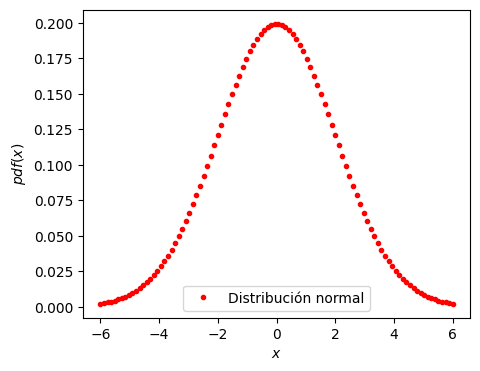

In [ ]:
x = np.linspace(-6, 6, 100)
y = norm(0, 2).pdf(x) #mu=mean es 1 y sigma es 2
#figure
plt.figure(figsize=(5,4))
plt.plot(x, y, 'r.', lw=3, label='Distribución normal')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.legend(fontsize=10)
plt.show()

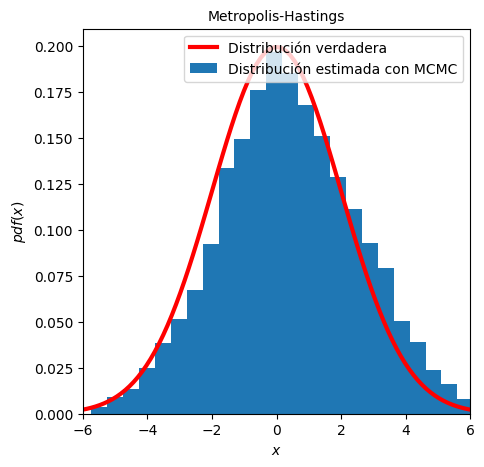

In [ ]:
from scipy.stats import norm
#*****************************************
#     Algorith: Metropolis-Hasting
#*****************************************
def metropolis(func, steps=10000):
    """A very simple Metropolis implementation"""
    muestras = np.zeros(steps)
    old_x = func.mean()
    old_prob = func.pdf(old_x)

    for i in range(steps):
        new_x = old_x + np.random.normal(0, 0.5)
        new_prob = func.pdf(new_x)
        aceptacion = new_prob / old_prob
        if aceptacion >= np.random.random():
            muestras[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            muestras[i] = old_x

    return muestras

# distribución normal
func = norm(0, 2)
samples = metropolis(func=func)#read the normal distribution
x = np.linspace(-6, 7, 100)
y = func.pdf(x)
plt.figure(figsize=(5,5))
plt.xlim(-6, 6)
plt.plot(x, y, 'r-', lw=3, label='Distribución verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10)
plt.show()

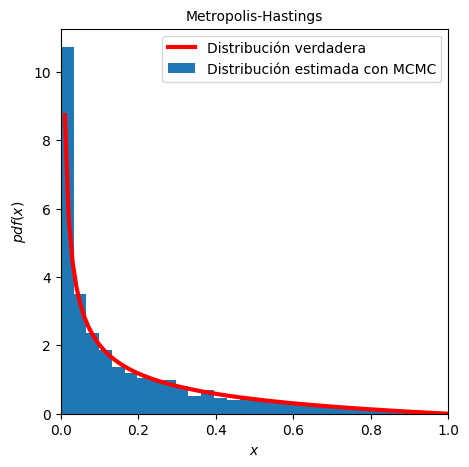

In [ ]:
# distribución beta
from scipy.stats import beta
func = beta(0.4, 2)

samples = metropolis(func=func)
x = np.linspace(0, 1, 100)
y = func.pdf(x)
plt.figure(figsize=(5,5))
plt.xlim(0, 1)
plt.plot(x, y, 'r-', lw=3, label='Distribución beta verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10)
plt.show()

**Ejemplo** Básico en Python **(Metropolis para una distribución normal**):

El método Metropolis-Hastings en Python utiliza cadenas de Markov para generar muestras aleatorias de una distribución de probabilidad compleja. Es un algoritmo MCMC (Markov Chain Monte Carlo) que acepta o rechaza nuevos estados basados en la razón de densidades de probabilidad, útil en física, estadística bayesiana y optimización.

(array([0.00031798, 0.        , 0.        , 0.00063597, 0.00063597,
        0.        , 0.00127194, 0.00381581, 0.0041338 , 0.00731364,
        0.00858558, 0.01589922, 0.020351  , 0.02321286, 0.03020852,
        0.04833363, 0.06709472, 0.07281844, 0.09412339, 0.10461688,
        0.12115207, 0.14150307, 0.16439795, 0.17330152, 0.1961964 ,
        0.19428849, 0.19905826, 0.19683237, 0.19492446, 0.17234756,
        0.16121811, 0.13959517, 0.12496788, 0.11479238, 0.09094355,
        0.06932061, 0.06009906, 0.04769767, 0.02957255, 0.02543875,
        0.02066899, 0.01303736, 0.0101755 , 0.00794961, 0.00286186,
        0.00095395, 0.00127194, 0.00095395, 0.        , 0.00095395]),
 array([-8.32953212, -8.01505132, -7.70057052, -7.38608972, -7.07160891,
        -6.75712811, -6.44264731, -6.12816651, -5.81368571, -5.49920491,
        -5.18472411, -4.87024331, -4.55576251, -4.24128171, -3.92680091,
        -3.61232011, -3.29783931, -2.98335851, -2.66887771, -2.35439691,
        -2.03991611, -1.72

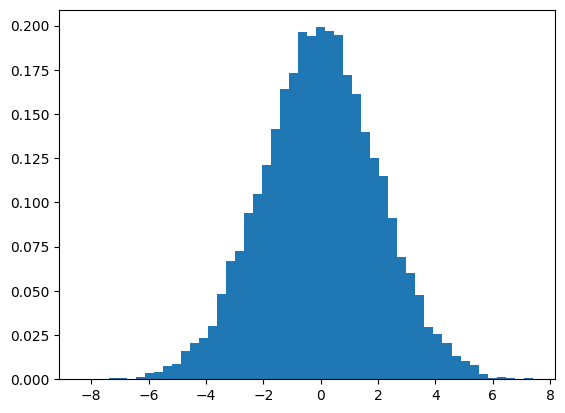

In [ ]:
#x = np.linspace(-6, 6, 1000)
y = np.random.normal(0,2,10000)
#plt.plot(x, y, 'r.', lw=3, label='Distribución normal')
plt.hist(y, bins=50,  density=True)

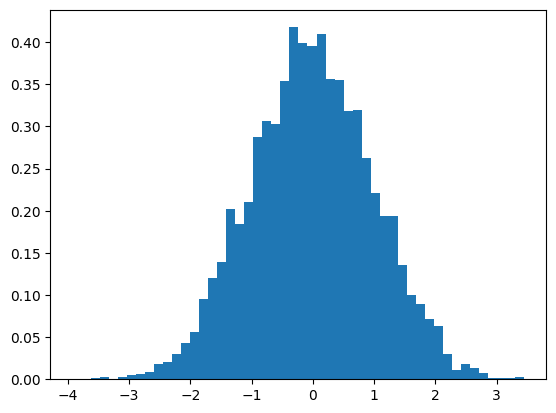

In [ ]:
#**********************************
#   Version 1
#**********************************
import numpy as np
import matplotlib.pyplot as plt

# Definir la distribución objetivo (ej. una distribución normal)
def objetivo(x):
    return np.exp(-0.5 * x**2) # Gaussiana simple

# Algoritmo de Metropolis
def metropolis(n_iter=10000, sigma=1.0):
    x = 0.0 # Estado inicial
    muestras = []
    for _ in range(n_iter):
        x_prop = x + np.random.normal(0, sigma) # Proponer nuevo estado

        # Calcular cociente de aceptación
        p_actual = objetivo(x)
        p_prop = objetivo(x_prop)

        if np.random.rand() < (p_prop / p_actual): #new random
            x = x_prop # Aceptar

        muestras.append(x)
    return np.array(muestras)

# Generar muestras
muestras = metropolis(10000)

# Visualizar resultados
plt.hist(muestras, bins=50, density=True)
plt.show()